In [51]:
#const=0
import numpy as np
import matplotlib.pyplot as plt

def derivative_value(q, u, k, E):
    return (-q**3 - 3*k*q**2 -3*k**2*q+u*q + k*u - k**3)*(-1)/E

def get_all_roots_1(u, k, E):
    # 四元方程系数: a*q^4 + b*q^3 + c*q^2 + d*q + e = 0
    a = -1
    b = -4*k
    c = -6*k**2 + 2*u
    d = -4*k**3+4*u*k
    e = E**2 - u**2 + 2*k**2*u - k**4
    
    # 使用numpy直接求解四元方程
    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    # 排序并获取四个根
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
    # 检查所有根的虚部是否都为0（纯实数根）
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        # 只有在所有根都是实数时才进行导数分类
        q_positive = []  # 导数 >= 0 的根
        q_negative = []  # 导数 < 0 的根
        
        for root in roots_sorted:
            # 使用实部计算导数
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)
        
        # 排序（按实部）
        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)
        
        # 分类
        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q33, q11 = q_negative_sorted[0], q_negative_sorted[1]

    else:
        if E<0 and k>0:
        # 如果有复数根，直接使用原来的排序
            q11, q22, q33, q44 = roots_sorted
        if E>0 and k>0:
        # 如果有复数根，直接使用原来的排序
            q11, q22, q33, q44 = roots_sorted
        if E<0 and k<0:
        # 如果有复数根，直接使用原来的排序
            q11, q22, q33, q44 = roots_sorted
        if E>0 and k<0:
        # 如果有复数根，直接使用原来的排序
            q11, q22, q33, q44 = roots_sorted

    return q11, q22, q33, q44



C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\7923310.py:62: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\7923310.py:62: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\7923310.py:62: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\7923310.py:62: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\7923310.py:62: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\7923310.py:62: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current f

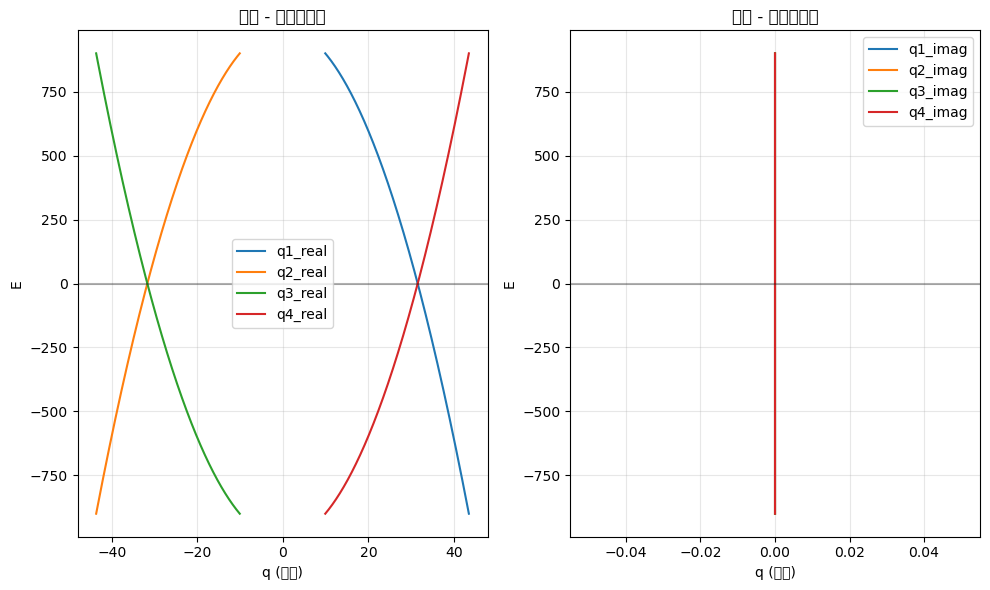

In [53]:
u = 1000
k =0.1
q1_real = []
q2_real = []
q3_real = []
q4_real = []
q1_imag = []
q2_imag = []
q3_imag = []
q4_imag = []
E_set = np.linspace(-900*const, 900*const, 10000)

for E in E_set:
    # 使用新的分类方法获取根
    q111, q222, q333, q444 = get_all_roots_1(u, k,  E)
    
    # 存储根的实部和虚部
    q1_real.append(q111.real)
    q2_real.append(q222.real)
    q3_real.append(q333.real)
    q4_real.append(q444.real)
    
    q1_imag.append(q111.imag)
    q2_imag.append(q222.imag)
    q3_imag.append(q333.imag)
    q4_imag.append(q444.imag)

# 绘制实部
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(q1_real, E_set, label='q1_real')
plt.plot(q2_real, E_set, label='q2_real')
plt.plot(q3_real, E_set, label='q3_real')
plt.plot(q4_real, E_set, label='q4_real')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('q (实部)')
plt.ylabel('E')
plt.title('实部 - 按导数分类')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(-8,8)
#plt.ylim(-1,1)
#plt.ylim(-360,-380)
#plt.xlim(31,31.25)
#plt.xlim(-32,-30)
#plt.ylim(370,375)

# 绘制虚部
plt.subplot(1, 2, 2)
plt.plot(q1_imag, E_set, label='q1_imag')
plt.plot(q2_imag, E_set, label='q2_imag')
plt.plot(q3_imag, E_set, label='q3_imag')
plt.plot(q4_imag, E_set, label='q4_imag')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('q (虚部)')
plt.ylabel('E')
plt.title('虚部 - 按导数分类')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(-8,8)

plt.tight_layout()
plt.show()

In [86]:
import numpy as np
import matplotlib.pyplot as plt

def derivative_value(q, u, k, E):
    return (-q**3 - 3*k*q**2 -3*k**2*q+u*q + k*u - k**3)*(-2)/E

def get_all_roots(u, k, const, E):
    # 四元方程系数: a*q^4 + b*q^3 + c*q^2 + d*q + e = 0
    a = -1
    b = -4*k
    c = -6*k**2 + 2*u
    d = -4*k**3+4*u*k
    e = E**2 - u**2 + 2*k**2*u - k**4-const**2
    
    # 使用numpy直接求解四元方程
    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    # 排序并获取四个根
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
    # 检查所有根的虚部是否都为0（纯实数根）
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        # 只有在所有根都是实数时才进行导数分类
        q_positive = []  # 导数 >= 0 的根
        q_negative = []  # 导数 < 0 的根
        
        for root in roots_sorted:
            # 使用实部计算导数
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)
        
        # 排序（按实部）
        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)
        
        # 分类
        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]

    else:
        if E<0 and k>0:
        
            q22, q11, q44, q33= roots_sorted
        if E>0 and k>0:
        
            q11, q22, q33, q44 = roots_sorted
        if E<0 and k<0:
       
            q22, q11, q44, q33 = roots_sorted
        if E>0 and k<0:
        
            q11, q22, q33, q44 = roots_sorted

    return q11, q22, q33, q44

C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1261486307.py:64: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1261486307.py:64: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1261486307.py:64: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1261486307.py:64: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1261486307.py:64: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1261486307.py:64: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) miss

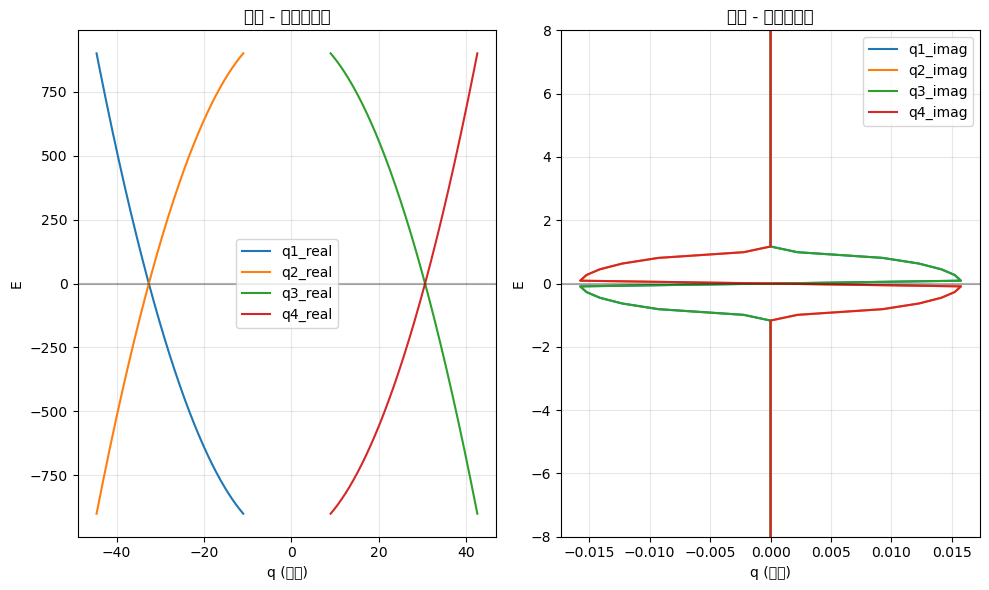

In [87]:
u = 1000
k = 1*10**(0)
const = u/1000
q1_real = []
q2_real = []
q3_real = []
q4_real = []
q1_imag = []
q2_imag = []
q3_imag = []
q4_imag = []
E_set = np.linspace(-900*const, 900*const, 10000)

for E in E_set:
    q111, q222, q333, q444 = get_all_roots(u, k, const, E)
    
    q1_real.append(q111.real)
    q2_real.append(q222.real)
    q3_real.append(q333.real)
    q4_real.append(q444.real)
    
    q1_imag.append(q111.imag)
    q2_imag.append(q222.imag)
    q3_imag.append(q333.imag)
    q4_imag.append(q444.imag)

# 绘制实部
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(q1_real, E_set, label='q1_real')
plt.plot(q2_real, E_set, label='q2_real')
plt.plot(q3_real, E_set, label='q3_real')
plt.plot(q4_real, E_set, label='q4_real')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('q (实部)')
plt.ylabel('E')
plt.title('实部 - 按导数分类')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(0,20)
#plt.ylim(-1,1)
#plt.ylim(-360,-380)
#plt.xlim(10.00,20.09)
#plt.xlim(-32,-30)
#plt.ylim(370,375)
#plt.axhline(y=373.61, color='green', linestyle='-', linewidth=1, alpha=0.7)

# 绘制虚部
plt.subplot(1, 2, 2)
plt.plot(q1_imag, E_set, label='q1_imag')
plt.plot(q2_imag, E_set, label='q2_imag')
plt.plot(q3_imag, E_set, label='q3_imag')
plt.plot(q4_imag, E_set, label='q4_imag')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('q (虚部)')
plt.ylabel('E')
plt.title('虚部 - 按导数分类')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(370,375)
#plt.axhline(y=373.61, color='green', linestyle='-', linewidth=1, alpha=0.7)
plt.ylim(-8,8)

plt.tight_layout()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1782975122.py:64: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1782975122.py:64: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1782975122.py:64: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1782975122.py:64: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1782975122.py:64: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\1782975122.py:64: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) miss

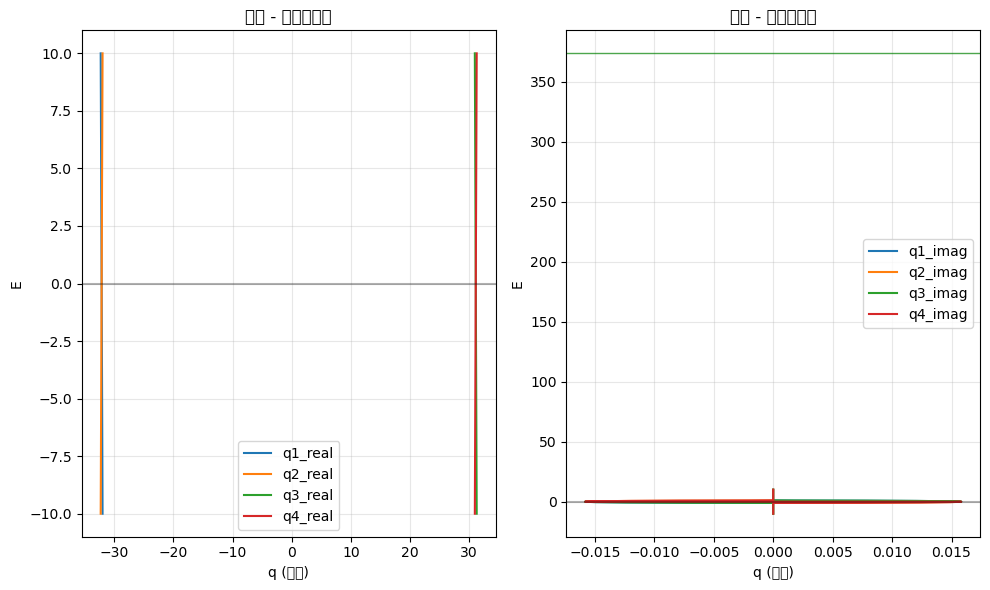

In [88]:
u = 1000
k = 0.5
const = u/1000
q1_real = []
q2_real = []
q3_real = []
q4_real = []
q1_imag = []
q2_imag = []
q3_imag = []
q4_imag = []
E_set = np.linspace(-10*const, 10*const, 10000)

for E in E_set:
    q111, q222, q333, q444 = get_all_roots(u, k, const, E)
    
    q1_real.append(q111.real)
    q2_real.append(q222.real)
    q3_real.append(q333.real)
    q4_real.append(q444.real)
    
    q1_imag.append(q111.imag)
    q2_imag.append(q222.imag)
    q3_imag.append(q333.imag)
    q4_imag.append(q444.imag)

# 绘制实部
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(q1_real, E_set, label='q1_real')
plt.plot(q2_real, E_set, label='q2_real')
plt.plot(q3_real, E_set, label='q3_real')
plt.plot(q4_real, E_set, label='q4_real')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('q (实部)')
plt.ylabel('E')
plt.title('实部 - 按导数分类')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(-8,8)
#plt.ylim(-1,1)
#plt.ylim(-360,-380)
#plt.xlim(31.50,32.00)
#plt.xlim(-32,-30)
#plt.ylim(370,375)
#plt.axhline(y=373.61, color='green', linestyle='-', linewidth=1, alpha=0.7)

# 绘制虚部
plt.subplot(1, 2, 2)
plt.plot(q1_imag, E_set, label='q1_imag')
plt.plot(q2_imag, E_set, label='q2_imag')
plt.plot(q3_imag, E_set, label='q3_imag')
plt.plot(q4_imag, E_set, label='q4_imag')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('q (虚部)')
plt.ylabel('E')
plt.title('虚部 - 按导数分类')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(370,375)
plt.axhline(y=373.61, color='green', linestyle='-', linewidth=1, alpha=0.7)
#plt.ylim(-8,8)

plt.tight_layout()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\2961027422.py:64: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\2961027422.py:64: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\2961027422.py:64: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\2961027422.py:64: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\2961027422.py:64: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\taoji\AppData\Local\Temp\ipykernel_26044\2961027422.py:64: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) miss

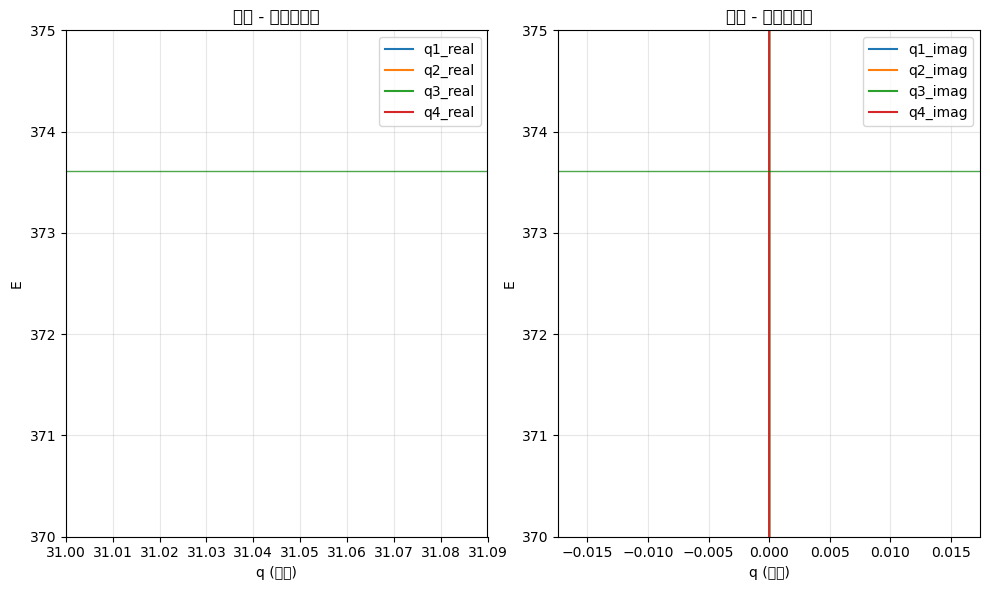

In [109]:
def calculate_probabilities_new_method(u, k, Z, E_set):
    const = u/1000
    H = 2*Z*(u)**0.5 
    
    a_set = []
    b_set = []
    c_set = []
    d_set = []
    z_set = []
    
    for E in E_set:
        qwei = abs(get_all_roots_1(u, k, E)[1])#*(-1)
        bf1 = 1
        bf2 = 0

        q3 = abs(get_all_roots(u, k, const, E)[1].real)+1j*abs(get_all_roots(u, k, const, E)[1].imag)
        af1 = -const/(((q3+k)**2-u-E)**2+const**2)**0.5
        af2 = ((q3+k)**2-u-E)/(((q3+k)**2-u-E)**2+const**2)**0.5

        q4 =  abs(get_all_roots(u, k, const, E)[3].real)+1j*abs(get_all_roots(u, k, const, E)[3].imag)
        cf1 = -const/(((q4+k)**2-u-E)**2+const**2)**0.5
        cf2 = ((q4+k)**2-u-E)/(((q4+k)**2-u-E)**2+const**2)**0.5

        q_e = abs(get_all_roots_1(u, k, E)[0])
        q_h = abs(get_all_roots_1(u, k, E)[2])

        dd1 = (qwei - q_h)*bf2 - ((q4 - q_h - H/(1j))*cf2*bf1*(qwei + q_e))/((q4 + q_e - H/(1j))*cf1)
        dd2 = (-1*q_e + q3 + H/(1j))*(q4 -q_h - H/(1j))*cf2*af1/((q4 + q_e - H/(1j))*cf1) + (-q_h -q3 - H/(1j))*af2
        
        d1 = dd1/dd2
        c1 = (d1*((-q_e + q3 + H/(1j))*af1) + (qwei + q_e)*bf1)/((q4 + q_e - H/(1j))*cf1)
        b1 = c1*cf1 + d1*af1 - bf1
        a1 = c1*cf2 + d1*af2 - bf2

        d11 = abs(d1)**2 * (abs(af2)**2 - abs(af1)**2) * q3.real / q_e+abs(d1)**2 * (abs(af2)**2 - abs(af1)**2) * k.real / q_e
        c11 = abs(c1)**2 * (abs(cf1)**2 - abs(cf2)**2) * q4.real*(1) / q_e+abs(c1)**2 * (abs(cf1)**2 - abs(cf2)**2) * k.real*(-1) / q_e
        b11 = abs(b1)**2 * 1 * (q_e) / q_e  
        a11 = abs(a1)**2 * 1 * (q_h) / q_e

        a_set.append(a11)
        b_set.append(b11)
        c_set.append(c11)
        d_set.append(d11)
        z_set.append(a11 + b11 + c11 + d11)
    
    return a_set, b_set, c_set, d_set,z_set

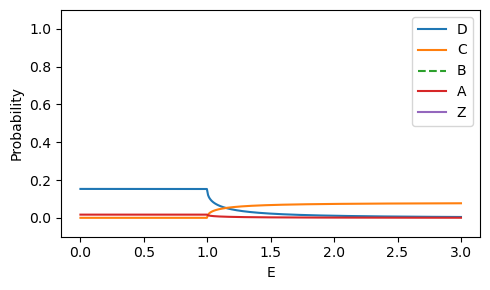

In [108]:
if __name__ == "__main__":
    u = 1000
    k = 10**(0)*6
    Z = 3
    c_val = u/1000
    
    E_set1 = np.linspace(0.001*c_val, 3*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1, z_set1 = calculate_probabilities_new_method(u, k, Z, E_set1)
    
    
    # 绘图
    plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.xlabel('E')
    plt.ylabel('Probability')
    plt.legend()
    plt.tight_layout()
    plt.ylim(-0.1,1.1)
    plt.show()

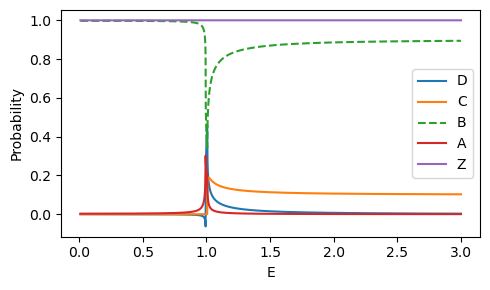

In [287]:
if __name__ == "__main__":
    u = 1000
    k = 10**(-4)
    Z = 3
    c_val = u/1000
    
    E_set1 = np.linspace(0.01*c_val, 3*c_val, 10000)
    a_set1, b_set1, c_set1, d_set1, z_set1 = calculate_probabilities_new_method(u, k, Z, E_set1)
    
    
    # 绘图
    plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.xlabel('E')
    plt.ylabel('Probability')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()

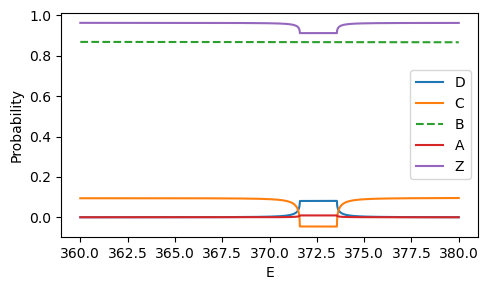

In [ ]:
if __name__ == "__main__":
    u = 1000
    k = 6
    Z = 3
    c_val = u/1000
    
    E_set1 = np.linspace(360*c_val, 380*c_val, 10000)
    a_set1, b_set1, c_set1, d_set1, z_set1 = calculate_probabilities_new_method(u, k, Z, E_set1)
    
    
    # 绘图
    plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.xlabel('E')
    plt.ylabel('Probability')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()